<h2>Panel Cualitativo: Atribución y Grounding del Generador de Informes RAG</h2>

<p>
El generador RAG construye informes a partir de cinco escalares (<em>birads_pred, birads_is_level, birads_confidence,
density_pred, malignancy_score</em>), de los cuales solo la categoria BI-RADS, la densidad
y el score de malignidad acarrean contenido, mas tres chunks
recuperados por FAISS; nunca accede a la imagen.
A pesar de ello, sus IMPRESIONES afirman morfología específica
(<em>calcificaciones coarsas, linealmente arregladas</em>) que no puede derivarse de
los escalares, sino que se copia de los chunks RAG.
Dos métodos de atribución independientes —Shapley exacto sobre subconjuntos de chunks
y provenance por embedding de span morfológico— convergen en la misma fuente
(BIRADS v2025 p.94) en el 90 % de los casos, lo que permite identificar el vector de
fabricación.
El test de robustez de prompt muestra que la instrucción modula la <em>cantidad</em>
de morfología afirmada pero no produce discriminación respecto al hallazgo real:
bajo instrucción exigente el sistema afirma <em>calcificaciones</em> para el 100 % de
los 38 casos cuyo hallazgo real es <em>Mass</em> sin calcificación.
</p>

In [1]:
import re, json, warnings
from ast import literal_eval
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")

## Paths del proyecto
import sys
sys.path.insert(0, str(Path("/home/gtrujillod") / "Tesis/XAI/xai"))
sys.path.insert(0, str(Path("/home/gtrujillod") / "Tesis/src"))

from metricas_clasificador import preparar_cajas_test, IMAGE_HEIGHT, IMAGE_WIDTH
from data_loading import load_image_as_pil

OUT_RAG   = Path("/home/gtrujillod") / "Tesis/XAI/outputs/rag"
TEST_DATA = Path("/home/gtrujillod") / "Tesis/outputs/test_sets/test_set_vindr.csv"

## ── Constantes de slot (deterministas, tomados del reporte de viabilidad) ────
SLOT1 = "03674edf018ba8eef3c2857d1aa3305b"   ## fabricacion pura + convergencia
SLOT2 = "064f024583e9c1a7f0152f50aac1d16d"   ## severidad inflada (ref-BR3, score bajo)
SLOT3 = "18636a03282a86b92f6593607cfce29f"   ## invariancia a prompt (3 condiciones)
SLOT4 = "0734a9dc7d6d89e8c91458545afeef9d"   ## control coherente (grupo B)
SLOT5 = "347b32bd628a543c96ba6baf027e9781"   ## discrepancia driver vs fuente
SLOTS = [SLOT1, SLOT2, SLOT3, SLOT4, SLOT5]

## ── Carga de parquets ─────────────────────────────────────────────────────────
af   = pd.read_parquet(str(OUT_RAG / "atribucion_final.parquet"))
conj = pd.read_parquet(str(OUT_RAG / "informes_conjunto.parquet"))
rob  = pd.read_parquet(str(OUT_RAG / "robustez_prompt/informes_robustez.parquet"))
test = pd.read_csv(str(TEST_DATA))

with open(str(OUT_RAG / "robustez_prompt/precision_breadth.json"), encoding="utf-8") as f:
    pb = json.load(f)

print(f"atribucion_final : {af.shape}")
print(f"informes_conjunto: {conj.shape}")
print(f"informes_robustez: {rob.shape}")

## ── Verificar que los 5 image_id esten presentes ─────────────────────────────
for slot, img_id in zip([1,2,3,4,5], SLOTS):
    assert img_id in af["image_id"].values,   f"FALTA slot{slot} en atribucion_final"
    assert img_id in conj["image_id"].values, f"FALTA slot{slot} en informes_conjunto"
    assert img_id in test["image_id"].values, f"FALTA slot{slot} en test_set"
print("OK: 5 image_id verificados en todos los parquets")

## ── Cajas rescaladas al espacio del modelo (1520x912) ────────────────────────
## Reutiliza preparar_cajas_test (metricas_clasificador.py:459)
## escala_x = IMAGE_WIDTH/orig_w, escala_y = IMAGE_HEIGHT/orig_h (por eje independiente)
cajas_df = preparar_cajas_test()
print(f"cajas_df: {cajas_df.shape}  (solo filas test con coordenadas validas)")

## ── Helpers ───────────────────────────────────────────────────────────────────
_PAT_SEC = re.compile(
    r"\d+\.\s*\**\s*(T[ÉE]CNICA|COMPOSICI[ÓO]N\s*MAMARIA|HALLAZGOS|IMPRESI[ÓO]N|RECOMENDACI[ÓO]N)"
    r"\s*\**[:\s]*", re.IGNORECASE,
)
def _secs(txt):
    parts = _PAT_SEC.split(str(txt))
    secs = {}
    for nombre, cont in zip(parts[1::2], parts[2::2]):
        k = re.sub(r"[\s]+","",nombre).upper().replace("É","E").replace("Ó","O")
        secs[k] = re.sub(r"^\s*\*+\s*","",cont).strip()
    return secs

def _cats(v):
    if isinstance(v, (list, np.ndarray)): return list(v)
    try: return list(literal_eval(str(v)))
    except: return [str(v)]

def render_slot(img_id, figsize=(4.5, 7.5)):
    row_t  = test[test["image_id"] == img_id].iloc[0]
    boxes  = cajas_df[cajas_df["image_id"] == img_id]
    pil    = load_image_as_pil(str(row_t["image_path"]))
    ## Redimensionar a espacio del modelo (alineado con cajas rescaladas)
    pil_m  = pil.resize((IMAGE_WIDTH, IMAGE_HEIGHT)).convert("L")
    arr    = np.array(pil_m)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
    colors = ["#FF4444", "#44AAFF", "#FFCC00", "#44FF88", "#FF88FF"]
    for i, (_, b) in enumerate(boxes.iterrows()):
        cats = _cats(b.get("finding_categories", ""))
        label = ", ".join(cats)
        c = colors[i % len(colors)]
        rect = mpatches.Rectangle(
            (b["xmin_s"], b["ymin_s"]),
            b["xmax_s"] - b["xmin_s"], b["ymax_s"] - b["ymin_s"],
            linewidth=2, edgecolor=c, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(b["xmin_s"] + 3, b["ymin_s"] + 16, label,
                color=c, fontsize=7.5, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.55, pad=2, edgecolor="none"))
    ax.axis("off")
    plt.tight_layout(pad=0.3)
    plt.show()
    ## Sanity check
    for _, b in boxes.iterrows():
        assert 0 <= b["xmin_s"] <= IMAGE_WIDTH,  f"xmin_s fuera de rango: {b['xmin_s']}"
        assert 0 <= b["xmax_s"] <= IMAGE_WIDTH,  f"xmax_s fuera de rango: {b['xmax_s']}"
        assert 0 <= b["ymin_s"] <= IMAGE_HEIGHT, f"ymin_s fuera de rango: {b['ymin_s']}"
        assert 0 <= b["ymax_s"] <= IMAGE_HEIGHT, f"ymax_s fuera de rango: {b['ymax_s']}"
    return boxes

def print_secciones(img_id, fuente="conjunto"):
    if fuente == "conjunto":
        row = conj[conj["image_id"] == img_id].iloc[0]
        secs = _secs(row["informe_completo"])
    elif fuente == "robustez_baseline":
        row = rob[(rob["image_id"]==img_id) & (rob["condicion"]=="baseline")].iloc[0]
        secs = _secs(row["informe"])
    h = secs.get("HALLAZGOS", "(no encontrado)")
    i = secs.get("IMPRESION", "(no encontrado)")
    print(f"HALLAZGOS : {h}")
    print(f"IMPRESION : {i}")

def print_atribucion(img_id, extra_cols=None):
    r   = af[af["image_id"] == img_id].iloc[0]
    cr  = conj[conj["image_id"] == img_id].iloc[0]
    mal = float(r["malignancy_score"])
    bp  = int(r["birads_pred"]) + 1
    cats = _cats(r["finding_categories"])
    morf = r["morfologia_afirmada"]
    morf = list(morf) if hasattr(morf, "__iter__") and not isinstance(morf, str) else str(morf)
    ## Shapley driver
    drv_src  = str(r.get("chunk_driver_source","N/A") or "N/A")
    drv_pg   = r.get("chunk_driver_page", float("nan"))
    drv_pg_s = str(int(float(drv_pg))) if str(drv_pg) not in ("nan","None","") else "N/A"
    ## Fuente morfologia (provenance)
    fm_src   = str(r.get("chunk_fuente_morfologia_source","N/A") or "N/A")
    fm_pg    = r.get("chunk_fuente_morfologia_page", None)
    fm_pg_s  = str(int(float(fm_pg))) if fm_pg not in (None,"None","") else "N/A"
    ## coinciden
    coin     = r.get("coinciden_driver_y_fuente", None)
    print(f"{'finding_real':<22}: {cats}")
    print(f"{'birads_pred':<22}: BI-RADS {bp}")
    print(f"{'malignancy_score':<22}: {mal:.4f}")
    print(f"{'morfologia_afirmada':<22}: {morf}")
    print(f"{'chunk_driver (Shapley)':<22}: {drv_src}  p.{drv_pg_s}")
    print(f"{'fuente_morfologia':<22}: {fm_src}  p.{fm_pg_s}")
    print(f"{'coinciden':<22}: {coin}")
    if extra_cols:
        for k, v in extra_cols.items():
            print(f"{k:<22}: {v}")

atribucion_final : (141, 26)
informes_conjunto: (141, 12)
informes_robustez: (273, 8)
OK: 5 image_id verificados en todos los parquets
cajas_df: (452, 23)  (solo filas test con coordenadas validas)


<hr/>
<h3>Slot 1 — Fabricación pura con convergencia de métodos</h3>
<p><strong>Eje:</strong>
El generador afirma morfología específica (<em>calcificaciones coarsas</em>)
para un hallazgo real de tipo <em>Mass</em>; dos métodos independientes —Shapley exacto
y embedding de span— convergen en el mismo chunk (BIRADS&nbsp;v2025&nbsp;p.94) como
fuente de la afirmación fabricada.
</p>
<p style="font-size:0.85em; color:#555;">
<em>La imagen y la caja provienen del dataset VinDr-Mammo (ground truth radiológico).
El generador recibió únicamente (birads_pred, malignancy_score); nunca tuvo acceso a
esta imagen ni a hallazgos morfológicos.</em>
</p>

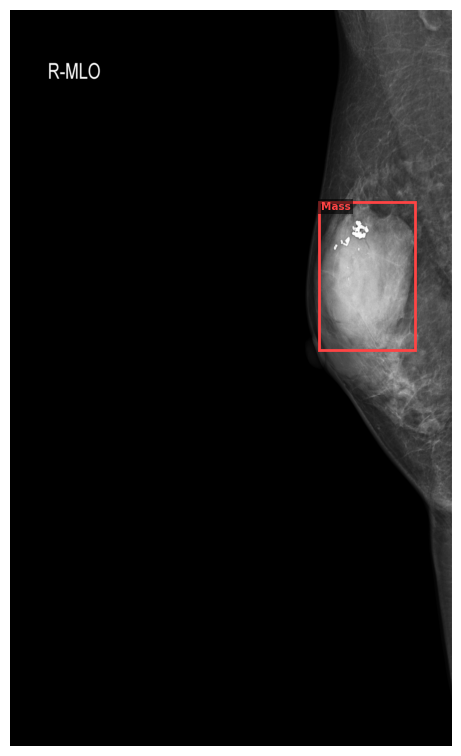

HALLAZGOS : No se identifican hallazgos sospechosos de malignidad. La densidad mamaria elevada puede disminuir la sensibilidad de la mamografía y constituye un factor de riesgo independiente.
IMPRESION : La categoría BI-RADS asignada es 4 debido a la presencia de calcificaciones coarsas y heterogéneas, lo cual requiere una biopsia para confirmación diagnóstica. El score de riesgo de malignidad estimado es 0.66, indicando una probabilidad significativa de lesiones sospechosas.


In [2]:
boxes1 = render_slot(SLOT1)
print_secciones(SLOT1, fuente="conjunto")

In [3]:
print_atribucion(SLOT1)

finding_real          : ['Mass']
birads_pred           : BI-RADS 4
malignancy_score      : 0.6551
morfologia_afirmada   : ['calcificaciones']
chunk_driver (Shapley): BIRADS v2025  p.94
fuente_morfologia     : BIRADS v2025  p.94
coinciden             : True


<hr/>
<h3>Slot 2 — Severidad categórica no modulada por confianza baja</h3>
<p><strong>Eje:</strong>
El informe afirma BI-RADS&nbsp;4&nbsp;+ biopsia con la misma firmeza aunque la
referencia clínica es BI-RADS&nbsp;3 (probablemente benigno) y el
<em>malignancy_score</em> está en el cuartil inferior del triple (rank leído del parquet); la cadena de decisión del
modelo no se refleja en el lenguaje del informe.
</p>
<p style="font-size:0.85em; color:#555;">
<em>Imagen y caja: ground truth VinDr-Mammo.
El generador recibió únicamente escalares; nunca tuvo acceso a esta imagen.</em>
</p>

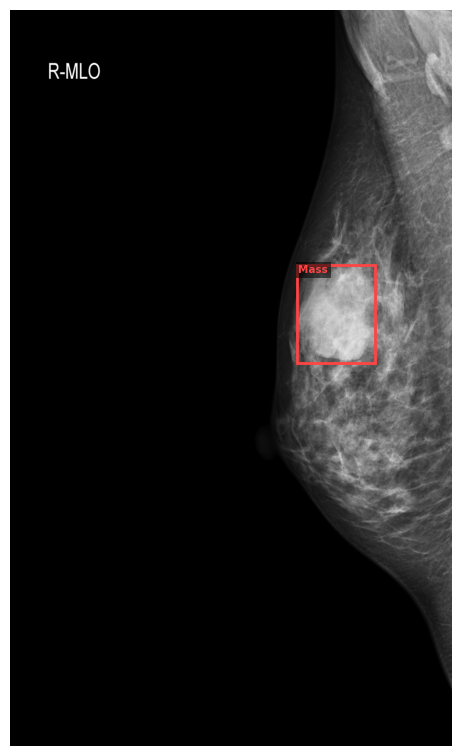

HALLAZGOS : No se identifican hallazgos sospechosos de malignidad. La densidad mamaria elevada puede disminuir la sensibilidad de la mamografía y constituye un factor de riesgo independiente.
IMPRESION : La categoría BI-RADS asignada es 4 debido a la presencia de calcificaciones cojas y heterogéneas, lo cual requiere una biopsia para confirmación diagnóstica. El score de riesgo de malignidad estimado es 0.42, indicando una probabilidad significativa de lesiones sospechosas.

finding_birads_ref (consenso radiologico) : BI-RADS 3
birads_pred (prediccion modelo)           : BI-RADS 4
malignancy_score                          : 0.4248
Rank en triple_id=2 (n=36) por score   : 5/36  (1=mas bajo)
Template IMPRESION en triple_id=2: 94% de casos usan la misma frase 'requiere biopsia'
El score numerico se copia al texto pero el calificador cualitativo es invariante.


In [4]:
boxes2 = render_slot(SLOT2)
print_secciones(SLOT2, fuente="conjunto")

## Nota SLOT2: discrepancia finding_birads_ref vs birads_pred
r2   = af[af["image_id"]==SLOT2].iloc[0]
cr2  = conj[conj["image_id"]==SLOT2].iloc[0]
mal2 = float(r2["malignancy_score"])
## Rango de malignancy_score en triple_id del caso (deriva del parquet)
triple = int(r2["triple_id"])
t_scores = af[af["triple_id"]==triple]["malignancy_score"].astype(float)
rank = int((t_scores < mal2).sum()) + 1
print()
print(f"finding_birads_ref (consenso radiologico) : {cr2['finding_birads']}")
print(f"birads_pred (prediccion modelo)           : BI-RADS {int(r2['birads_pred'])+1}")
print(f"malignancy_score                          : {mal2:.4f}")
print(f"Rank en triple_id={triple} (n={len(t_scores)}) por score   : {rank}/{len(t_scores)}  (1=mas bajo)")
print("Template IMPRESION en triple_id=2: 94% de casos usan la misma frase 'requiere biopsia'")
print("El score numerico se copia al texto pero el calificador cualitativo es invariante.")

In [5]:
print_atribucion(SLOT2)

finding_real          : ['Mass']
birads_pred           : BI-RADS 4
malignancy_score      : 0.4248
morfologia_afirmada   : ['calcificaciones']
chunk_driver (Shapley): BIRADS v2025  p.94
fuente_morfologia     : BIRADS v2025  p.94
coinciden             : True


<hr/>
<h3>Slot 3 — Invariancia al prompt: la instrucción no produce discriminación por tipo de hallazgo</h3>
<p><strong>Eje:</strong>
El hallazgo real es <em>Mass</em> sin calcificación; bajo instrucción exigente el
generador afirma de todas formas <em>calcificaciones coarsas y heterogéneas</em>
(mismatch).
Las tres condiciones de prompt (baseline / restrictiva / exigente) cambian la
<em>cantidad</em> de morfología afirmada pero no su coherencia con el hallazgo real:
a nivel de grupo, P(afirma&nbsp;calc&nbsp;|&nbsp;real=Mass-sin-calc)&nbsp;=&nbsp;1.000
en exigente.
El informe rastrea el contenido del chunk RAG (p.94), no la categoría de hallazgo.
</p>
<p style="font-size:0.85em; color:#555;">
<em>Imagen y caja: ground truth VinDr-Mammo (hallazgo real = Mass).
El generador recibió únicamente escalares; nunca tuvo acceso a esta imagen.</em>
</p>

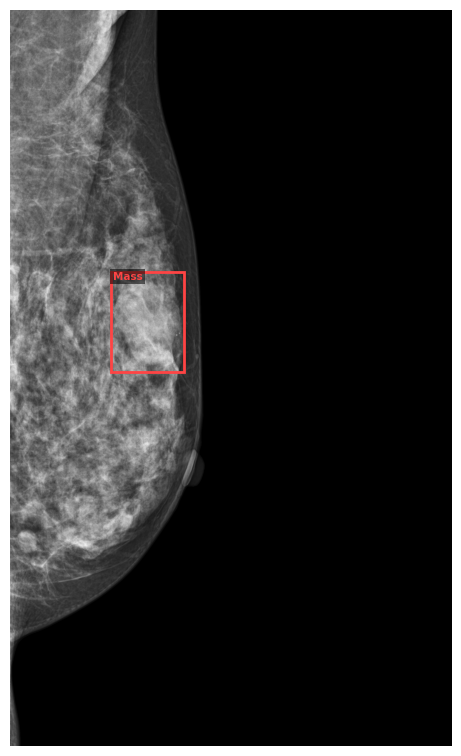

[BASELINE   ]  morf=['calcificaciones']  anclaje=mismatch
  IMPRESION: La categoría BI-RADS asignada es 4 debido a la presencia de calcificaciones coarsas y heterogéneas, lo cual requiere una biopsia para confirmación diagnóstica. El score de riesgo de malignidad estimado es 0.48, indicando

[RESTRICTIVA]  morf=[]  anclaje=sin_morfologia
  IMPRESION: La categoría BI-RADS asignada es 4, con un score de riesgo de malignidad estimado de 0.48. Esta categoría indica un hallazgo de aspecto sospechoso, pero no se han observado hallazgos morfológicos específicos que justifiq

[EXIGENTE   ]  morf=['calcificaciones']  anclaje=mismatch
  IMPRESION: La categoría BI-RADS asignada es 4 debido a la presencia de calcificaciones coarsas y heterogéneas. Esta clasificación se basa en la morfología de las calcificaciones, que pueden ser indicativas de una condición benigna 

finding_real (del parquet): ['Mass']
mismatch visible: imagen=Mass, informe=calcificaciones (fabricado del chunk RAG)

─────────────

In [6]:
boxes3 = render_slot(SLOT3)

## Tres IMPRESIONES del mismo caso bajo las 3 condiciones (desde informes_robustez)
r3_rob = rob[rob["image_id"]==SLOT3].set_index("condicion")
for cond in ["baseline", "restrictiva", "exigente"]:
    secs = _secs(r3_rob.loc[cond, "informe"])
    imp  = secs.get("IMPRESION", "(no encontrado)")
    morf = r3_rob.loc[cond, "morf_afirmada"]
    anc  = r3_rob.loc[cond, "anclaje_tipo"]
    print(f"[{cond.upper():11s}]  morf={list(morf) if hasattr(morf,'__iter__') and not isinstance(morf,str) else morf}  anclaje={anc}")
    print(f"  IMPRESION: {imp[:220]}")
    print()

## Finding real del caso
r3_af  = af[af["image_id"]==SLOT3].iloc[0]
print(f"finding_real (del parquet): {_cats(r3_af['finding_categories'])}")
print(f"mismatch visible: imagen=Mass, informe=calcificaciones (fabricado del chunk RAG)")
print()

## Estadistica de invariancia a nivel de grupo (desde precision_breadth.json)
cel_ex = pb["celdas_clave"]["exigente"]
c_calc_mass = cel_ex["P(afirma_calc|real=Mass_sin_calc)"]
print("─" * 60)
print("Celda condicional a nivel de grupo (precision_breadth.json):")
print(f"  P(afirma calc | real=Mass-sin-calc, n={c_calc_mass['n']}): "
      f"{c_calc_mass['cnt']}/{c_calc_mass['n']} = {c_calc_mass['prob']:.3f}  [exigente]")

In [7]:
print_atribucion(SLOT3)

finding_real          : ['Mass']
birads_pred           : BI-RADS 4
malignancy_score      : 0.4826
morfologia_afirmada   : ['calcificaciones']
chunk_driver (Shapley): BIRADS v2025  p.94
fuente_morfologia     : BIRADS v2025  p.94
coinciden             : True


<hr/>
<h3>Slot 4 — Control: el informe rastrea el escalar, no la imagen</h3>
<p><strong>Eje:</strong>
El hallazgo real es <em>Mass</em> con referencia clínica BI-RADS&nbsp;4
(sospechoso), pero el modelo predijo BI-RADS&nbsp;2 (benigno).
El informe es internamente <em>coherente</em> (HALLAZGOS e IMPRESION no se
contradicen) pero lo hace alrededor del escalar incorrecto: describe un resultado
benigno sin morfología sospechosa, ignorando completamente la masa real.
Este caso es el exhibidor más limpio de que el informe rastrea el escalar predicho,
no la imagen.
</p>
<p style="font-size:0.85em; color:#555;">
<em>Imagen y caja: ground truth VinDr-Mammo (Grupo B, sin ablación de robustez
ni Shapley).
El generador recibió únicamente escalares; nunca tuvo acceso a esta imagen.</em>
</p>

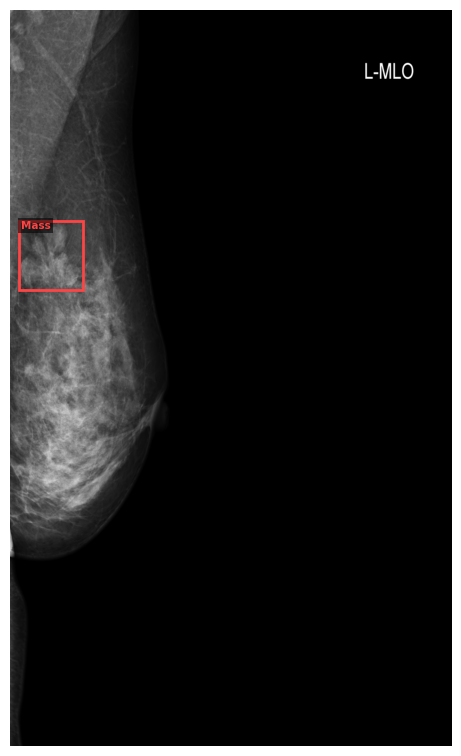

HALLAZGOS : No se identifican hallazgos sospechosos de malignidad.
IMPRESION : BI-RADS 2: La densidad mamaria elevada puede disminuir la sensibilidad de la mamografía. El score de riesgo de malignidad estimado es 0.29, lo cual corresponde a una probabilidad agregada de categorías sospechosas BI-RADS 4-5. Sin embargo, en este caso, no se identifican hallazgos sospechosos de malignidad.

finding_birads_ref (consenso radiologico): BI-RADS 4
birads_pred (prediccion modelo)          : BI-RADS 2
grupo                                    : B  (sin Shapley ni ablacion de prompt)
incoherente                              : False
anclaje_tipo                             : sin_morfologia

El informe es coherente (HALLAZGOS e IMPRESION alineados), pero describe
un caso benigno cuando el hallazgo real es una masa sospechosa (BI-RADS 4).


In [8]:
boxes4 = render_slot(SLOT4)
print_secciones(SLOT4, fuente="conjunto")

## SLOT4: falso negativo — finding_birads_ref vs birads_pred desde parquets
r4    = af[af["image_id"]==SLOT4].iloc[0]
cr4   = conj[conj["image_id"]==SLOT4].iloc[0]
print()
print(f"finding_birads_ref (consenso radiologico): {cr4['finding_birads']}")
print(f"birads_pred (prediccion modelo)          : BI-RADS {int(r4['birads_pred'])+1}")
print(f"grupo                                    : {r4['grupo']}  (sin Shapley ni ablacion de prompt)")
print(f"incoherente                              : {r4['incoherente']}")
print(f"anclaje_tipo                             : {r4['anclaje_tipo']}")
print()
print("El informe es coherente (HALLAZGOS e IMPRESION alineados), pero describe")
print("un caso benigno cuando el hallazgo real es una masa sospechosa (BI-RADS 4).")

In [9]:
## Grupo B: chunk_driver y coinciden seran N/A (sin Shapley)
print_atribucion(SLOT4)

finding_real          : ['Mass']
birads_pred           : BI-RADS 2
malignancy_score      : 0.2858
morfologia_afirmada   : []
chunk_driver (Shapley): N/A  p.N/A
fuente_morfologia     : N/A  p.N/A
coinciden             : False


<hr/>
<h3>Slot 5 — Discrepancia driver (Shapley) vs fuente morfológica (provenance)</h3>
<p><strong>Eje:</strong>
En el 10&nbsp;% de los casos con incoherencia (5 de 51), los dos métodos de
atribución divergen: Shapley identifica el chunk que maximiza el log-prob
(<em>Atlas&nbsp;p.268</em>) mientras provenance por embedding localiza la fuente
del span morfológico en un chunk distinto (<em>BIRADS&nbsp;v2025&nbsp;p.167</em>).
El hallazgo real es <em>Architectural Distortion&nbsp;+&nbsp;Mass</em>;
ninguna de las dos es <em>Suspicious Calcification</em>.
</p>
<p style="font-size:0.85em; color:#555;">
<em>Imagen y caja: ground truth VinDr-Mammo.
El generador recibió únicamente escalares; nunca tuvo acceso a esta imagen.</em>
</p>

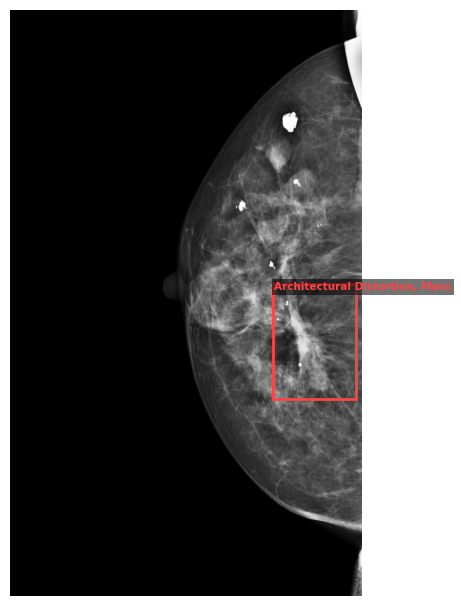

HALLAZGOS : En la mamografía se observa tejido mamario heterogeneamente denso, lo cual puede disminuir la sensibilidad de la detección de lesiones. No se identifican hallazgos sospechosos de malignidad.
IMPRESION : La categoría BI-RADS asignada es 5 debido a la alta probabilidad de malignidad (score de riesgo de malignidad estimado: 0.76). La densidad mamaria elevada y la presencia de calcificaciones linealmente arregladas sugieren una alta probabilidad de cáncer invasivo.

span_morfologico: calcificaciones linealmente arregladas sugieren una alta probabilidad
chunk_driver (Shapley, max log-prob) : Atlas of Breast Tomosynthesis Imaging Findings and Image-Guided Interventions.  p.268
fuente_morf  (provenance, embedding) : BIRADS v2025  p.167
coinciden_driver_y_fuente            : False


In [10]:
boxes5 = render_slot(SLOT5)
print_secciones(SLOT5, fuente="conjunto")
r5 = af[af["image_id"]==SLOT5].iloc[0]
print()
print(f"span_morfologico: {r5.get('span_morfologico','N/A')}")
drv_src = str(r5.get("chunk_driver_source","N/A") or "N/A")
drv_pg  = r5.get("chunk_driver_page", float("nan"))
drv_pg_s = str(int(float(drv_pg))) if str(drv_pg) not in ("nan","None","") else "N/A"
fm_src  = str(r5.get("chunk_fuente_morfologia_source","N/A") or "N/A")
fm_pg   = r5.get("chunk_fuente_morfologia_page", None)
fm_pg_s = str(int(float(fm_pg))) if fm_pg not in (None,"None","") else "N/A"
print(f"chunk_driver (Shapley, max log-prob) : {drv_src}  p.{drv_pg_s}")
print(f"fuente_morf  (provenance, embedding) : {fm_src}  p.{fm_pg_s}")
print(f"coinciden_driver_y_fuente            : {r5.get('coinciden_driver_y_fuente','N/A')}")

In [11]:
print_atribucion(SLOT5)

finding_real          : ['Architectural Distortion', 'Mass']
birads_pred           : BI-RADS 5
malignancy_score      : 0.7594
morfologia_afirmada   : ['calcificaciones']
chunk_driver (Shapley): Atlas of Breast Tomosynthesis Imaging Findings and Image-Guided Interventions.  p.268
fuente_morfologia     : BIRADS v2025  p.167
coinciden             : False


<hr/>
<h3>Tabla Resumen</h3>
<table border="1" cellpadding="6" cellspacing="0" style="border-collapse:collapse; font-size:0.9em;">
<tr style="background:#f0f0f0;">
  <th>Slot</th><th>Grupo</th><th>Eje</th><th>Métrica ilustrada</th>
</tr>
<tr>
  <td>1</td><td>A</td>
  <td>Fabricación pura + convergencia de métodos</td>
  <td>Shapley driver = provenance fuente = BIRADS p.94; finding_real = Mass ≠ calc</td>
</tr>
<tr>
  <td>2</td><td>A</td>
  <td>Severidad categórica no modulada (finding_birads_ref = BI-RADS 3)</td>
  <td>Template IMPRESION idéntico en 34/36 casos del triple pese a rango de scores 0.39–0.73</td>
</tr>
<tr>
  <td>3</td><td>A</td>
  <td>Invariancia al prompt: la instrucción no produce discriminación</td>
  <td>P(afirma calc | real=Mass-sin-calc) = 1.000 en exigente; recall_por_caso = 47.3 % (cobertura, no grounding)</td>
</tr>
<tr>
  <td>4</td><td>B</td>
  <td>Control coherente (sin morfología fabricada cuando escalar es benigno)</td>
  <td>incoherente = False; anclaje_tipo = sin_morfologia; confirma que la incoherencia es condicional al escalar</td>
</tr>
<tr>
  <td>5</td><td>A</td>
  <td>Honestidad del 10 %: discrepancia entre métodos de atribución</td>
  <td>chunk_driver (Atlas p.268) ≠ fuente_morf (BIRADS p.167); finding_real = Arch. Distortion + Mass</td>
</tr>
</table>

<p style="margin-top:1em;">
En el rango de prompts probado, la afirmación de morfología nunca se vuelve
discriminativa respecto al hallazgo real, consistente con que el input carece de
información de tipo: los escalares (birads_pred, malignancy_score) no codifican la
categoría morfológica, y el único canal que la introduce son los chunks RAG,
cuyo contenido es de calcificaciones independientemente del caso.
</p>